## 1. Import Libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import lightgbm as lgb
from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Load environment variables from .env file
load_dotenv()

True

In [2]:
# Load the upload keys from environment variables
NAPI_PUBLIC_ID = os.getenv("NAPI_PUBLIC_ID_UPLOAD")
NAPI_SECRET_KEY = os.getenv("NAPI_SECRET_KEY_UPLOAD")

## 2. Initialization & Data Download

In [3]:
from time import time

print(f"\n{'=' * 80}")
print("NUMERAI DATA PIPELINE - INITIALIZATION".center(80))
print(f"{'=' * 80}\n")

napi = NumerAPI(public_id=NAPI_PUBLIC_ID, secret_key=NAPI_SECRET_KEY)
DATA_VERSION = "v5.2"
MAIN_TARGET = "target_ender_20"
DATA_DIR = "../../data"

# Create data directory if it doesn't exist
os.makedirs(DATA_DIR, exist_ok=True)

# Download essential files
files = [
    "train.parquet", 
    "validation.parquet", 
    "live.parquet", 
    "features.json",
    "validation_benchmark_models.parquet",
    "live_benchmark_models.parquet"
]

download_start = time()
for file in files:
    file_path = os.path.join(DATA_DIR, DATA_VERSION, file)
    
    if os.path.exists(file_path):
        print(f"✓ {file:<40} [CACHED]")
    else:
        print(f"⬇ {file:<40} [DOWNLOADING...]", end="", flush=True)
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        napi.download_dataset(f"{DATA_VERSION}/{file}", dest_path=file_path)
        print(f"\r✓ {file:<40} [DOWNLOADED]")

download_time = time() - download_start
print(f"\n⏱ Total download time: {download_time:.2f}s\n")

# Load Feature Metadata
feature_metadata = json.load(open(os.path.join(DATA_DIR, DATA_VERSION, "features.json")))
feature_set = feature_metadata["feature_sets"]["small"]  # Use 'small' for faster iteration

print(f"📋 Feature Set: 'small' ({len(feature_set)} features)")
print(f"{'=' * 80}\n")


                     NUMERAI DATA PIPELINE - INITIALIZATION                     

✓ train.parquet                            [CACHED]
✓ validation.parquet                       [CACHED]
✓ live.parquet                             [CACHED]
✓ features.json                            [CACHED]
✓ validation_benchmark_models.parquet      [CACHED]
✓ live_benchmark_models.parquet            [CACHED]

⏱ Total download time: 0.00s

📋 Feature Set: 'small' (42 features)



## 3. Data Loading & Pre-processing

In [4]:
print(f"\n{'=' * 80}")
print("DATA LOADING & PREPROCESSING".center(80))
print(f"{'=' * 80}\n")

load_start = time()

# Load Training Data
MAIN_TARGET = "target"

print(f"📥 Loading training data...", end="", flush=True)
train = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"), 
    columns=["era", MAIN_TARGET] + feature_set
)
print(f"\r✓ Training data loaded: {len(train):,} rows")

# Load Validation Data & Benchmarks
print(f"📥 Loading validation data...", end="", flush=True)
validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), 
    columns=["era", MAIN_TARGET] + feature_set
)
val_benchmarks = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")
)
print(f"\r✓ Validation data loaded: {len(validation):,} rows")

# Load Live Data & Benchmarks
print(f"📥 Loading live data...", end="", flush=True)
live = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"), 
    columns=["era"] + feature_set
)
live_benchmarks = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "live_benchmark_models.parquet")
)
print(f"\r✓ Live data loaded: {len(live):,} rows")

# Apply 4-era Embargo to prevent leakage
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(eras_to_embargo)]

load_time = time() - load_start

print(f"\n⚠️  Applied 4-era embargo: Removed {len(eras_to_embargo)} eras from validation")
print(f"📊 Training eras: {train['era'].nunique()}")
print(f"📊 Validation eras: {validation['era'].nunique()}")
print(f"📊 Live eras: {live['era'].nunique()}")
print(f"\n⏱ Total load time: {load_time:.2f}s")
print(f"{'=' * 80}\n")


                          DATA LOADING & PREPROCESSING                          

✓ Training data loaded: 2,746,268 rows
✓ Validation data loaded: 3,943,998 rows
✓ Live data loaded: 7,128 rows

⚠️  Applied 4-era embargo: Removed 4 eras from validation
📊 Training eras: 574
📊 Validation eras: 630
📊 Live eras: 1

⏱ Total load time: 5.18s



In [5]:
# Print era range of training and validation sets
print(f"(1) Training Era Range: {train['era'].min()} to {train['era'].max()}")
print(f"(2) Validation Era Range: {validation['era'].min()} to {validation['era'].max()}\n")

(1) Training Era Range: 0001 to 0574
(2) Validation Era Range: 0579 to 1208



In [6]:
# Print all target columns in the dataset
target_columns = [col for col in train.columns if col.startswith("target_")]
for t in target_columns:
    print(f"- {t}")

## 4. Prediction Engine

Implement your ML model logic here.

In [7]:
import pandas as pd
import lightgbm as lgb
from numerai_tools.scoring import numerai_corr

def prediction_engine(train_df, val_df, live_df, features):
    """
    Refined Single-Target Pipeline using v5 Deep Parameters.
    """

    print(f"🚀 Training on {MAIN_TARGET} with Deep LGBM params...")

    # Parameters optimized for high performance on v5 data 
    model = lgb.LGBMRegressor(
        n_estimators=30000,      # High tree count for deep signal extraction 
        learning_rate=0.001,     # Slow learning rate for stability 
        max_depth=10,            # Deep trees to capture complex non-linearities 
        num_leaves=1024,         # High leaf count for model capacity 
        colsample_bytree=0.1,    # Feature subsampling to reduce overfitting 
        min_data_in_leaf=10000,  # Prevents overfitting to small stock clusters 
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )

    # Train with early stopping to prevent over-optimization on training eras 
    model.fit(
        train_df[features],
        train_df[MAIN_TARGET],
        eval_set=[(val_df[features], val_df[MAIN_TARGET])],
        callbacks=[
            lgb.early_stopping(stopping_rounds=200), 
            lgb.log_evaluation(period=100)
        ]
    )

    print(f"✅ Training complete. Best iteration: {model.best_iteration_}")

    # Generate predictions
    # Note: We rank-transform them (0-1) to match the required submission format [cite: 40, 321]
    val_preds = pd.Series(model.predict(val_df[features])).rank(pct=True).values
    live_preds = pd.Series(model.predict(live_df[features])).rank(pct=True).values

    return val_preds, live_preds, model

## 5. Generate Predictions

In [8]:
# Execute Engine
val_predictions, live_predictions, trained_model = prediction_engine(train, validation, live, feature_set)

# Assign to dataframes for scoring
validation["prediction"] = val_predictions
live["prediction"] = live_predictions

print(f"\n{'=' * 80}")
print("PREDICTIONS SUMMARY".center(80))
print(f"{'=' * 80}")
print(f"Validation predictions: {len(val_predictions):,}")
print(f"Live predictions: {len(live_predictions):,}")
print(f"Validation range: [{val_predictions.min():.6f}, {val_predictions.max():.6f}]")
print(f"Live range: [{live_predictions.min():.6f}, {live_predictions.max():.6f}]")
print(f"{'=' * 80}\n")

🚀 Training on target with Deep LGBM params...
Training until validation scores don't improve for 200 rounds
[100]	valid_0's l2: 0.0518206
[200]	valid_0's l2: 0.0518201
[300]	valid_0's l2: 0.0518196
[400]	valid_0's l2: 0.0518192
[500]	valid_0's l2: 0.0518188
[600]	valid_0's l2: 0.0518184
[700]	valid_0's l2: 0.0518181
[800]	valid_0's l2: 0.0518177
[900]	valid_0's l2: 0.0518174
[1000]	valid_0's l2: 0.051817
[1100]	valid_0's l2: 0.0518167
[1200]	valid_0's l2: 0.0518165
[1300]	valid_0's l2: 0.0518162
[1400]	valid_0's l2: 0.0518159
[1500]	valid_0's l2: 0.0518157
[1600]	valid_0's l2: 0.0518155
[1700]	valid_0's l2: 0.0518152
[1800]	valid_0's l2: 0.051815
[1900]	valid_0's l2: 0.0518148
[2000]	valid_0's l2: 0.0518146
[2100]	valid_0's l2: 0.0518144
[2200]	valid_0's l2: 0.0518143
[2300]	valid_0's l2: 0.0518141
[2400]	valid_0's l2: 0.051814
[2500]	valid_0's l2: 0.0518138
[2600]	valid_0's l2: 0.0518137
[2700]	valid_0's l2: 0.0518135
[2800]	valid_0's l2: 0.0518134
[2900]	valid_0's l2: 0.0518133
[3000

In [9]:
# # Analyze feature importance (if model supports it)
# if trained_model is not None:
#     feature_importance_df = analyze_feature_importance(trained_model, feature_set, top_n=20)

## 6. Metrics & Similarity Analysis

In [11]:
# Add repo root to path so `utils` package is importable.
import sys
# This notebook lives at models/v0.2/ — two levels up is the repo root.
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

In [12]:
from pathlib import Path
from utils.metrics import calculate_metrics
from utils.visualization import display_metrics_table, plot_performance_diagnostics
from utils.model_benchmark import record_model_metrics, compare_top_models_with_current

In [ ]:
# Replaced by shared implementation in utils.visualization.plot_performance_diagnostics

In [ ]:
# Replaced by shared implementation in utils.visualization.display_metrics_table

## 7. Display Results

In [13]:
# Calculate comprehensive metrics
metrics, per_era_df = calculate_metrics(
    df_validation=validation,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col="v52_lgbm_ender20",
)

                        KEY PERFORMANCE METRICS vs GOALS                        



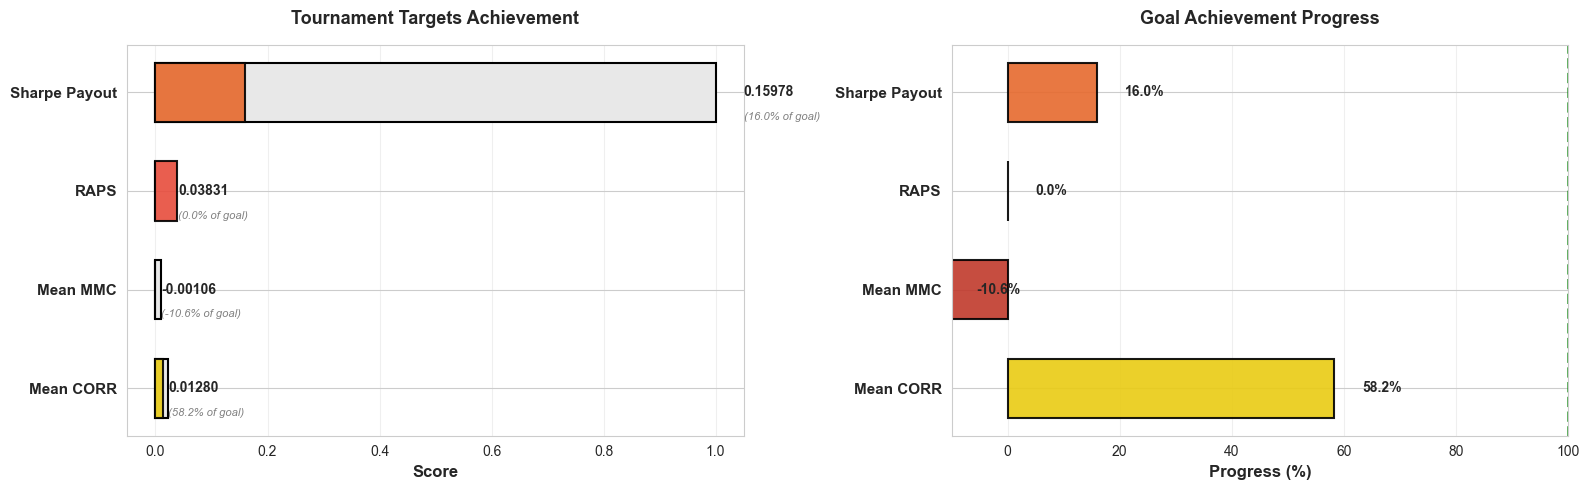

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,+0.0383,+0,✅ MET,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00106,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.01280,+0.022,🟠 LAGGING,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.9236,+1,🟡 CLOSE,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.1598,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01050,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.06680,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00788,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,81.8%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.4248,+0.2,🔴 EXCEEDED,95th percentile of strongest single-feature correlation


In [14]:
# Display professional metrics table
display_metrics_table(metrics, extended=True)

## 7.1 Benchmark Against Previous Models

In [15]:
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.1.ipynb")).stem
history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=notebook_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=3,
    show_message=True,
 )

print("\nMODEL LEADERBOARD (Top 3 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)


MODEL LEADERBOARD (Top 3 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,1_hello_numerai_modified,c7fae6f9,-0.000914,0.012383,0.0774,0.1610,2026-03-01 21:40:09,False
1,2,finance_arena_v0.1,2c663abc,-0.001063,0.012799,0.0383,0.1598,2026-03-01 22:05:13,True
2,3,2_feature_neutralization_modified,24ee6099,-0.001069,0.012318,0.0744,0.1483,2026-03-01 21:42:15,False


In [16]:
# Visualize performance diagnostics
#plot_performance_diagnostics(per_era_df, metrics)

# 8. Export PKL model

In [17]:
assert False

AssertionError: 

In [ ]:
# Export model to pkl file
import joblib
joblib.dump(trained_model, 'finance_arena_v0.1.pkl')